# 511090 基础统计分析

这个 notebook 只读取 `../data/` 下已经由 `../code/analyze.py` 生成的 CSV，不直接读取原始 snapshot。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
ROOT_DIR = Path.cwd().resolve().parent
DATA_DIR = ROOT_DIR / 'data'

if not DATA_DIR.exists():
    raise FileNotFoundError('cannot locate sh511090/data; run ../code/analyze.py first')

print(f'data_dir = {DATA_DIR}')

data_dir = /home/jovyan/work/tactics_demo/sh511090/data


In [3]:
def read_csv(name: str, index_col: int | None = 0) -> pd.DataFrame:
    path = DATA_DIR / f'{name}.csv'
    if not path.exists():
        raise FileNotFoundError(f'missing {path}; run ../code/analyze.py first')
    return pd.read_csv(path, index_col=index_col)

headline = read_csv('headline')
spread = read_csv('spread', index_col=None)
price = read_csv('price')
turnover = read_csv('turnover')
trade = read_csv('trade')
price_change = read_csv('price_change')
depth = read_csv('depth')
activity = read_csv('activity', index_col=None)
daily = read_csv('daily', index_col=None)
sample = read_csv('sample', index_col=None)
valid_dates = read_csv('valid_dates', index_col=None)

## Headline

In [4]:
headline.T

,0
instrument_id,5.110900e+05
start_ymd,2.026010e+07
end_ymd,2.026042e+07
trade_days,3.700000e+01
snapshots,5.328740e+05
tick_size,1.000000e-03
avg_price_last,1.146378e+02
avg_spread_ticks,2.926311e+00
one_tick_spread_ratio,2.610523e-01
avg_turnover_per_sec,3.196588e+05


In [5]:
valid_dates.head(), valid_dates.tail()

(   trade_ymd
 0   20260105
 1   20260107
 2   20260109
 3   20260113
 4   20260115,
     trade_ymd
 32   20260413
 33   20260415
 34   20260417
 35   20260421
 36   20260423)

## Spread / Turnover / Price Change

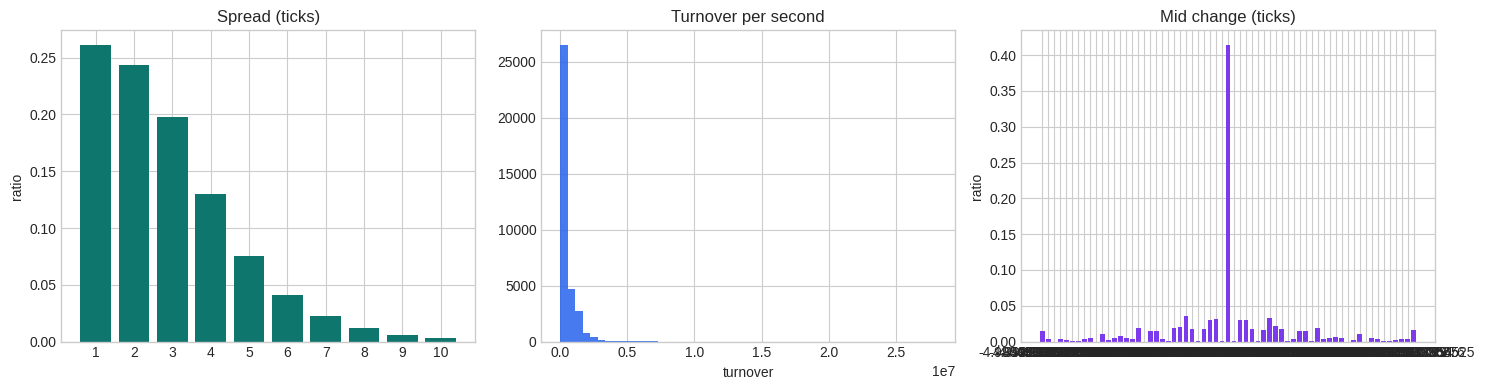

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

spread_view = spread.loc[spread['spread_ticks'] <= 10].copy()
axes[0].bar(spread_view['spread_ticks'].astype(str), spread_view['ratio'], color='#0f766e')
axes[0].set_title('Spread (ticks)')
axes[0].set_ylabel('ratio')

turnover_positive = sample.loc[sample['turnover'] > 0, 'turnover']
axes[1].hist(turnover_positive, bins=50, color='#2563eb', alpha=0.85)
axes[1].set_title('Turnover per second')
axes[1].set_xlabel('turnover')

mid_change_dist = sample['mid_change_ticks'].clip(-5, 5).value_counts(normalize=True).sort_index()
axes[2].bar(mid_change_dist.index.astype(str), mid_change_dist.values, color='#7c3aed')
axes[2].set_title('Mid change (ticks)')
axes[2].set_ylabel('ratio')

plt.tight_layout()

## Summary Tables

In [7]:
price

,price_last,mid_price
q00,112.800000,112.800500
q25,113.989000,113.988500
q50,114.573000,114.573000
q75,115.548000,115.548500
q100,116.909000,116.908000
mean,114.637815,114.637843
std,0.921870,0.921877


In [8]:
turnover

,turnover
q00,0.000000e+00
q25,0.000000e+00
q50,7.935920e+04
q75,3.881814e+05
q90,9.927135e+05
q95,1.372354e+06
q99,2.577654e+06
q100,5.195412e+07
mean,3.196588e+05
std,6.223151e+05


In [9]:
trade

,trade_volume,trade_count_delta
q00,0.000000,0.000000
q25,0.000000,0.000000
q50,700.000000,2.000000
q75,3400.000000,5.000000
q90,8700.000000,8.000000
q99,22500.000000,20.000000
q100,453000.000000,374.000000
mean,2790.729642,3.291465
std,5436.832995,5.011519


In [10]:
price_change

,mid_change_ticks,last_price_change_ticks
q00,-70.000000,-110.000000
q01,-6.000000,-7.000000
q05,-3.000000,-4.000000
q25,-0.500000,0.000000
q50,0.000000,0.000000
q75,0.500000,0.000000
q95,3.000000,4.000000
q99,6.000000,7.000000
q100,57.500000,120.000000
mean,-0.001212,-0.000950


In [11]:
depth

,bid1_vol,ask1_vol,l1_depth,l5_depth,imbalance_l1
mean,3908.943542,3931.828079,7840.771621,43058.285298,-0.006443
q00,1.000000,1.000000,122.000000,2068.000000,-0.999600
q01,NaN,NaN,NaN,NaN,-0.976471
q05,NaN,NaN,NaN,NaN,-0.933333
q100,890100.000000,818400.000000,894000.000000,965400.000000,0.999960
q25,500.000000,500.000000,2400.000000,26300.000000,-0.600000
q50,1800.000000,1900.000000,4900.000000,34200.000000,0.000000
q75,4300.000000,4400.000000,9000.000000,45700.000000,0.590698
q90,8300.000000,8700.000000,14900.000000,63500.000000,NaN
q95,NaN,NaN,NaN,NaN,0.931034


## Intraday Activity

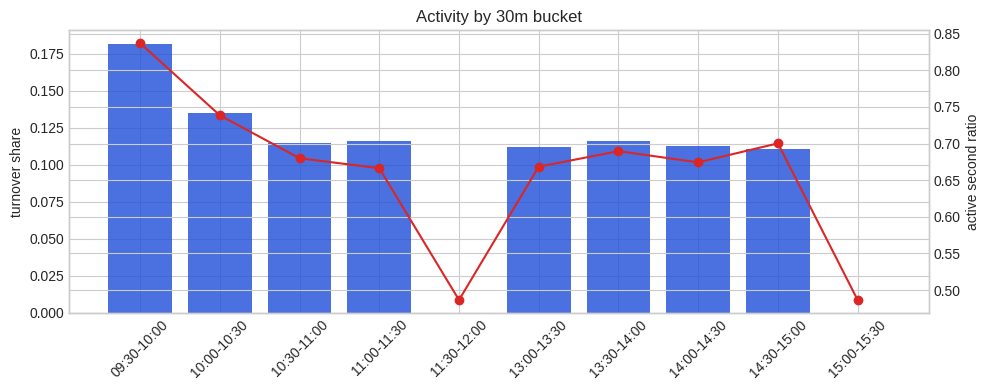

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(activity['bucket_30m'], activity['turnover_share'], color='#1d4ed8', alpha=0.8)
ax1.set_ylabel('turnover share')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(activity['bucket_30m'], activity['active_second_ratio'], color='#dc2626', marker='o')
ax2.set_ylabel('active second ratio')
ax1.set_title('Activity by 30m bucket')

plt.tight_layout()

In [13]:
activity

,Unnamed: 0,bucket_30m,seconds,turnover_sum,avg_turnover_per_sec,median_turnover_per_sec,avg_trade_count_per_sec,avg_trade_volume_per_sec,active_second_ratio,avg_spread_ticks,turnover_share
0,0,09:30-10:00,66600,3.095397e+10,464774.365438,172910.10,4.745330,4060.213724,0.837072,3.573709,0.181721
1,1,10:00-10:30,66600,2.302579e+10,345732.538651,102702.75,3.529069,3019.517703,0.738559,2.841426,0.135177
2,2,10:30-11:00,66600,1.958301e+10,294039.197273,58174.00,3.096426,2566.184114,0.679970,2.847282,0.114966
3,3,11:00-11:30,66600,1.978540e+10,297078.133117,57788.00,3.018453,2593.794309,0.666366,2.874174,0.116154
4,4,11:30-12:00,37,3.426334e+06,92603.627027,0.00,1.135135,808.108108,0.486486,3.729730,0.000020
5,5,13:00-13:30,66600,1.911917e+10,287074.665099,57707.05,2.997778,2505.074880,0.668453,2.889339,0.112243
6,6,13:30-14:00,66600,1.971359e+10,295999.894407,68451.80,3.073904,2583.661066,0.689640,2.787282,0.115732
7,7,14:00-14:30,66600,1.924853e+10,289016.934133,57796.50,2.907057,2522.628288,0.674384,2.782628,0.113002
8,8,14:30-15:00,66600,1.890291e+10,283827.550041,58152.00,2.966186,2477.146141,0.700315,2.814009,0.110973
9,9,15:00-15:30,37,2.046539e+06,55311.872973,0.00,0.972973,483.783784,0.486486,3.270270,0.000012


## Daily Summary

In [14]:
daily

,Unnamed: 0,trade_ymd,snapshots,avg_price_last,avg_spread_ticks,turnover_sum,avg_turnover_per_sec,active_second_ratio,avg_l1_depth,avg_l5_depth,mid_volatility_ticks
0,0,20260105,14402,113.947414,2.908346,5.947934e+09,412993.597704,0.733926,7654.727538,38214.602555,2.249180
1,1,20260107,14402,113.072715,2.705944,7.392133e+09,513271.250045,0.822455,8047.184141,43545.187613,2.302129
2,2,20260109,14402,113.109084,2.419872,7.788141e+09,540767.992901,0.888974,8959.489585,44447.113665,2.257705
3,3,20260113,14402,113.512403,3.048188,5.733392e+09,398096.914583,0.754479,8419.580822,48701.530135,2.042218
4,4,20260115,14402,113.603287,2.482780,5.922836e+09,411250.928950,0.819817,6509.767463,37336.726219,1.985807
5,5,20260119,14402,113.466993,2.713720,5.371604e+09,372976.283897,0.750660,12470.345230,80445.488752,2.016730
6,6,20260121,14402,114.347140,3.089918,6.413733e+09,445336.285559,0.818289,7778.324330,45599.102694,2.268013
7,7,20260123,14402,114.885288,2.507360,5.636570e+09,391374.109200,0.833843,6158.556242,38297.192751,2.184855
8,8,20260127,14402,114.984231,3.391543,5.359918e+09,372164.823414,0.790862,7058.721011,39404.992362,2.139695
9,9,20260129,14402,115.161159,3.071032,4.296245e+09,298308.940807,0.745521,6544.410499,37637.390640,2.243042
